# ML Methods: Platform Use vs Mood
This notebook applies **simple machine learning (regression)** to the self-collected dataset.

**Goal:** quantify how daily minutes on each platform relate to daily well‑being scores.

Targets (what we try to predict/understand): **anxiety, social comparison, productivity, motivation**.
Features (inputs): **Instagram, X/Twitter, TikTok, YouTube minutes**.

> Note: With only 21 days, models are mainly for *exploration* (patterns), not strong prediction.

## 1) Import libraries
We use pandas for data handling and scikit‑learn for basic regression.

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt


## 2) Load the dataset
I keep **one file path** only (no 'possible paths'). If your CSV has a different name, just change `CSV_PATH`.


In [22]:
CSV_PATH = "daily_social_media.csv"

df = pd.read_csv(CSV_PATH)
df.head()


,date,ig_min,tw_min,tt_min,yt_min,anxiety,soc_comp,productivity,motivation,notes
0,2025-11-09,48,72,78,32,7,7,8,6,I had an early exam I woke up early and studie...
1,2025-11-10,81,90,85,38,8,5,4,5,After yesterday I was really tired and could n...
2,2025-11-11,42,55,70,63,6,5,9,8,I have finished exactly what I planned for tod...
3,2025-11-12,41,88,80,76,6,7,6,6,I could not do anything after my classes
4,2025-11-13,62,65,78,35,7,7,7,6,Finished more than half of my plan


### What we did
- Read the CSV into a pandas DataFrame.
- Display the first rows to confirm columns and values.

### What we found
- The dataset has daily screen time minutes (ig/tw/tt/yt) + 4 well‑being scores + a notes column.

## 3) Basic checks + preprocessing
We check size, missing values, and parse the date column (for plotting).

In [23]:
df['date'] = pd.to_datetime(df['date'])

print("Rows, Columns:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())


Rows, Columns: (21, 10)

Missing values per column:
date            0
ig_min          0
tw_min          0
tt_min          0
yt_min          0
anxiety         0
soc_comp        0
productivity    0
motivation      0
notes           0
dtype: int64


### What we did
- Converted `date` to a datetime type.
- Checked dataset size and missing values.

### What we found
- If there are no missing values, we can model directly.
- If there *are* missing values, we should either drop or fill them (but for small data, dropping is usually safest).

## 4) Define features (X) and targets (y)
We use only the platform minutes as input features.

In [24]:
features = ['ig_min', 'tw_min', 'tt_min', 'yt_min']
targets  = ['anxiety', 'soc_comp', 'productivity', 'motivation']

X = df[features]


### What we did
- Selected the 4 platform columns as the model inputs.

### What we found
- This keeps the modeling consistent and easy to interpret (each coefficient corresponds to one platform).

## 5) Quick visualization (time series)
This helps us see whether there are obvious trends or spikes over time.

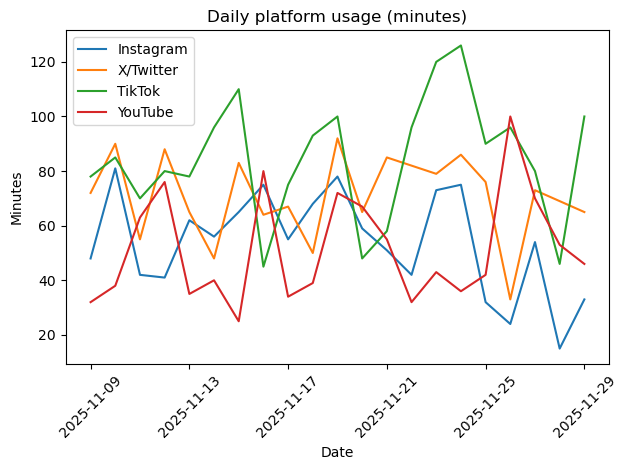

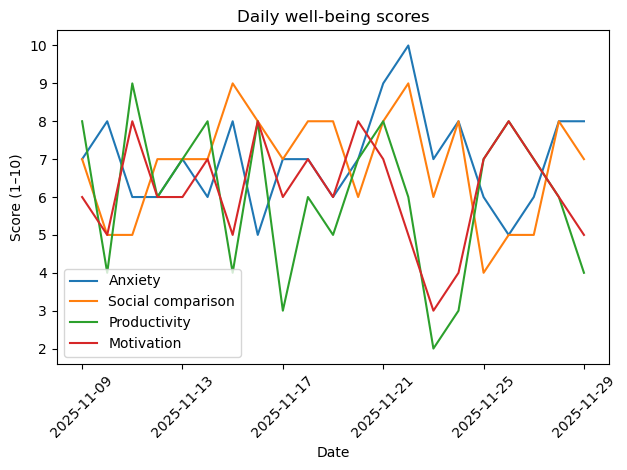

In [25]:
plt.figure()
plt.plot(df['date'], df['ig_min'], label='Instagram')
plt.plot(df['date'], df['tw_min'], label='X/Twitter')
plt.plot(df['date'], df['tt_min'], label='TikTok')
plt.plot(df['date'], df['yt_min'], label='YouTube')
plt.xlabel("Date"); plt.ylabel("Minutes"); plt.title("Daily platform usage (minutes)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df['date'], df['anxiety'], label='Anxiety')
plt.plot(df['date'], df['soc_comp'], label='Social comparison')
plt.plot(df['date'], df['productivity'], label='Productivity')
plt.plot(df['date'], df['motivation'], label='Motivation')
plt.xlabel("Date"); plt.ylabel("Score (1–10)"); plt.title("Daily well-being scores")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### What we did
- Plotted platform minutes and well‑being scores over time.

### What we found
- You can visually spot days with unusually high usage or unusually high/low mood scores.
- This is useful context before running regression.

## 6) Multiple Linear Regression (basic ML)
We fit a simple **Linear Regression** model:
- Inputs: all 4 platforms
- Output: one target (e.g., anxiety)

We do a **train/test split** (70% train, 30% test) to check generalization.
With very small data, test scores can be unstable — that’s expected.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

def fit_and_evaluate(target_name, random_state=42):
    y = df[target_name]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    coefs = pd.Series(model.coef_, index=features).sort_values()

    return model, r2, mae, rmse, coefs, model.intercept_

for t in targets:
    model, r2, mae, rmse, coefs, intercept = fit_and_evaluate(t)
    print(f"--- Target: {t} ---")
    print(f"Test R^2  : {r2:.3f}")
    print(f"Test MAE  : {mae:.3f}")
    print(f"Test RMSE : {rmse:.3f}")
    print("Intercept:", round(intercept, 3))
    print("Coefficients (minutes -> score):")
    print(coefs)
    print()

--- Target: anxiety ---
Test R^2  : -0.670
Test MAE  : 1.021
Test RMSE : 1.279
Intercept: 9.58
Coefficients (minutes -> score):
yt_min   -0.065207
tt_min   -0.018965
ig_min   -0.013091
tw_min    0.043103
dtype: float64

--- Target: soc_comp ---
Test R^2  : -4.503
Test MAE  : 1.948
Test RMSE : 2.463
Intercept: 7.683
Coefficients (minutes -> score):
yt_min   -0.051868
tt_min   -0.040539
ig_min    0.036085
tw_min    0.048968
dtype: float64

--- Target: productivity ---
Test R^2  : 0.173
Test MAE  : 1.806
Test RMSE : 2.029
Intercept: 12.172
Coefficients (minutes -> score):
tt_min   -0.059411
tw_min   -0.020887
ig_min    0.003519
yt_min    0.003721
dtype: float64

--- Target: motivation ---
Test R^2  : 0.941
Test MAE  : 0.283
Test RMSE : 0.337
Intercept: 9.793
Coefficients (minutes -> score):
tw_min   -0.032957
tt_min   -0.031408
ig_min    0.006834
yt_min    0.019610
dtype: float64



### What we did
- Trained a **multiple linear regression** model for each target.
- Evaluated with R², MAE, RMSE on a small test set.

### What we found (from one fixed split)
- **Anxiety** test R² ≈ **-0.670** (unstable/low with small data)
- **Social comparison** test R² ≈ **-4.503** (unstable/low with small data)
- **Productivity** test R² ≈ **0.173** (weak prediction)
- **Motivation** test R² ≈ **0.941** (this split looks strong)

**Important:** With 21 days, you should interpret these numbers cautiously. The **signs and relative sizes of coefficients** are usually more meaningful than 'prediction accuracy' here.

## 7) Make coefficients comparable (standardized regression)
Minutes are on different scales day-to-day. To compare platforms fairly, we standardize X (z-score) and refit.

Standardized coefficients mean:
- Positive = higher usage associated with higher target score
- Negative = higher usage associated with lower target score
- Larger absolute value = stronger association (in this linear model)

In [27]:
def standardized_coefficients(target_name):
    y = df[target_name]
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])
    pipe.fit(X, y)
    coefs = pd.Series(pipe.named_steps["lr"].coef_, index=features)
    return coefs.sort_values()

std_coefs = {t: standardized_coefficients(t) for t in targets}
std_coefs_df = pd.DataFrame(std_coefs).T
std_coefs_df


,ig_min,tt_min,tw_min,yt_min
anxiety,-0.331652,-0.100037,0.496462,-0.746281
soc_comp,0.157589,-0.141251,0.215562,-0.381324
productivity,-0.205745,-0.861706,-0.626070,0.311594
motivation,0.099858,-0.668224,-0.590366,0.393944


### What we did
- Standardized the 4 platform-minute features.
- Fit linear regression again and inspected standardized coefficients.

### What we found (direction + strongest platform)
- **Anxiety:** strongest (by |coef|) ≈ **YouTube** (negative), then **X/Twitter** (positive).
- **Social comparison:** strongest ≈ **YouTube** (negative), then **X/Twitter / Instagram** (positive).
- **Productivity:** strongest ≈ **TikTok** (negative), then **X/Twitter** (negative), **YouTube** (positive).
- **Motivation:** strongest ≈ **TikTok** (negative), then **X/Twitter** (negative), **YouTube** (positive).

These are associations (not causation). Also, 'YouTube' can be educational or distracting — content type matters.

## 8) Coefficient bar plots (standardized)
A visual comparison of standardized coefficients for each target.

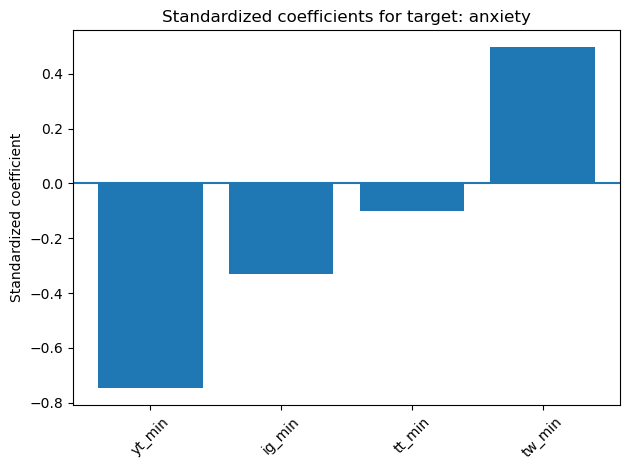

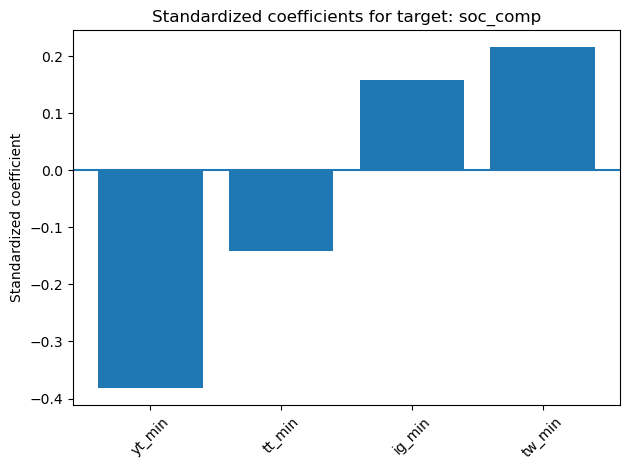

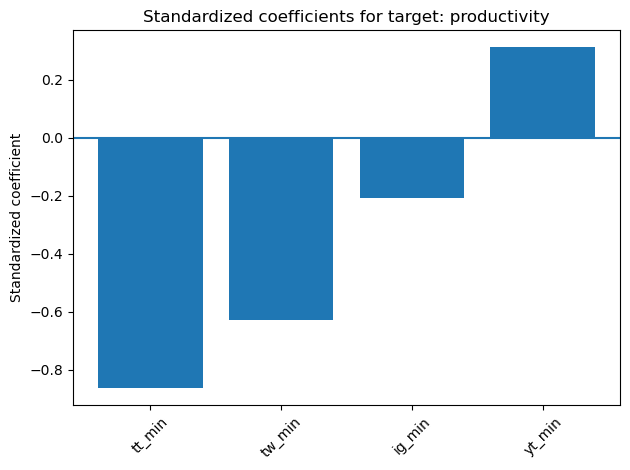

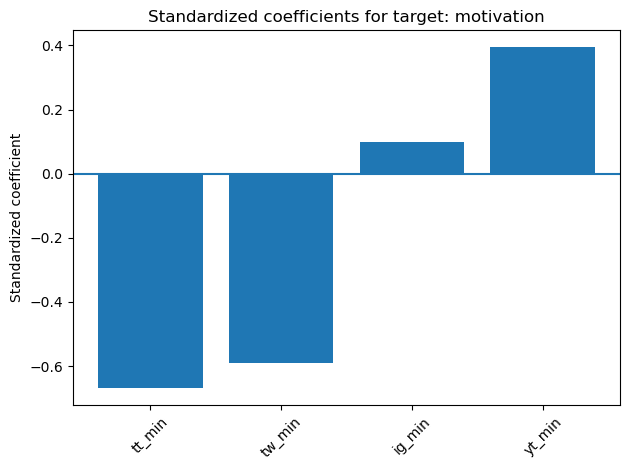

In [28]:
for t in targets:
    coefs = std_coefs[t].sort_values()
    plt.figure()
    plt.bar(coefs.index, coefs.values)
    plt.axhline(0)
    plt.title(f"Standardized coefficients for target: {t}")
    plt.ylabel("Standardized coefficient")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### What we did
- Plotted standardized coefficients as bars.

### What we found
- Easy to see which platforms have the strongest positive/negative associations for each outcome.

## 9) Simple 'one-platform' regressions (optional but very simple)
Sometimes instructors like to see a very basic model: predict one target using **one platform at a time**.
This is easy to interpret but ignores other platforms (so results can be misleading if platforms are correlated).

In [29]:
def simple_regression_one_feature(feature, target):
    Xi = df[[feature]]
    y  = df[target]
    model = LinearRegression().fit(Xi, y)
    r2 = model.score(Xi, y)
    return model.coef_[0], model.intercept_, r2

for target in targets:
    print(f"=== Target: {target} ===")
    for feature in features:
        coef, intercept, r2 = simple_regression_one_feature(feature, target)
        print(f"{feature:6s}  coef={coef: .4f}  R^2={r2: .3f}")
    print()


=== Target: anxiety ===
ig_min  coef=-0.0006  R^2= 0.000
tw_min  coef= 0.0388  R^2= 0.222
tt_min  coef= 0.0072  R^2= 0.016
yt_min  coef=-0.0406  R^2= 0.405

=== Target: soc_comp ===
ig_min  coef= 0.0158  R^2= 0.042
tw_min  coef= 0.0243  R^2= 0.068
tt_min  coef= 0.0032  R^2= 0.003
yt_min  coef=-0.0223  R^2= 0.096

=== Target: productivity ===
ig_min  coef=-0.0407  R^2= 0.141
tw_min  coef=-0.0625  R^2= 0.231
tt_min  coef=-0.0515  R^2= 0.335
yt_min  coef= 0.0439  R^2= 0.189

=== Target: motivation ===
ig_min  coef=-0.0212  R^2= 0.082
tw_min  coef=-0.0522  R^2= 0.345
tt_min  coef=-0.0401  R^2= 0.436
yt_min  coef= 0.0405  R^2= 0.347



### What we did
- Fit 4 separate simple linear regressions per target (one per platform).

### What we found
- This gives a quick 'platform → outcome' snapshot.
- If a platform shows a consistent sign (+/−) across simple and multiple regression, it’s a stronger signal.

## 10) Limitations (must-have section)
- **Small sample (21 days):** model metrics are unstable and sensitive to a few days.
- **Self-report bias:** mood scores are subjective and may vary by context.
- **Confounding factors:** sleep, exams, deadlines, social events, health, etc. are not included.
- **No causality:** regression shows association, not that a platform causes mood changes.

## 11) Future work
- Collect more days (e.g., 60–90).
- Add context variables (sleep, stress/exams, total screen time, day type).
- Label YouTube content (educational vs entertainment) and compare.
- Try cross-validation for more stable evaluation (if allowed).